<img src='https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/tools/frameworks/-/raw/main/img/Standard_banner.png' align='right' width='100%'/>

<a href="../../Index.ipynb"><< Index</a>
<br>

<font color="#138D75">**Copernicus Marine Training Service**</font> <br>
**Copyright:** 2026 European Union <br>
**License:** MIT <br>
**Authors:** Ben Loveday (EUMETSAT/Innoflair UG), Hayley Evers-King (EUMETSAT), Vinca Rosmorduc (CLS), Marcello Passaro (TUM)

<html>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/applications/altimetry-applications"><img src="https://img.shields.io/badge/open-EUMETLAB-E67E22.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://user.eumetsat.int/data/themes/marine"><img src="https://img.shields.io/badge/open-USER PORTAL-154360.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://mybinder.org/v2/git/https%3A%2F%2Fgitlab.eumetsat.int%2Feumetlab%2Foceans%2Focean-training%2Fapplications%2Faltimetry-applications/HEAD?labpath=2_methodological_approaches%2FComparing_retrackers%2FComparing_retrackers.ipynb"><img src="https://mybinder.org/badge_logo.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://jupyterhub.prod.wekeo2.eu/hub/user-redirect/lab/tree/public/wekeo4oceans/altimetry-applications/2_methodological_approaches/Comparing_retrackers/Comparing_retrackers.ipynb"><img src="https://img.shields.io/badge/launch-WEKEO-1a4696.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://code.insula.destine.eu/hub/"><img src="https://img.shields.io/badge/launch-DestinE-f43fd3.svg"></a></div></div>
</html>

# Comparing retrackers for Sentinel-6 low resolution products

For this module we will use both data from Sentinel-6 delivered by EUMETSAT (level-1, level-2, level-2P and level-3). As such, you will need to access data to the EUMETSAT Data Store.

### Data used

| Dataset | EUMETSAT collection ID| EUMETSAT collection<br>description | WEkEO dataset ID | WEkEO description |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:--------:|
| Sentinel-6 Poseidon-4 Altimetry level 1b Low Resolution  | EO:EUM:DAT:0852 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:0852" target="_blank">Description</a> | EO:EUM:DAT:0852 | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3A0852" target="_blank">Description</a> |
| Sentinel-6 Poseidon-4 Altimetry level 2 Low Resolution   | EO:EUM:DAT:0854 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:0854" target="_blank">Description</a> | EO:EUM:DAT:0854 | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3A0854" target="_blank">Description</a> |

### Learning outcomes

At the end of this notebook you will know;
* ...

### Outline

...

<div class="alert alert-info" role="alert">

## Table of contents

</div>
    
 1. [Importing dependencies](#Importing-dependencies)
 1. [Setting up our analysis](#Setting-up-our-analysis)
 1. [Defining functions](#Defining-functions)
 1. [Downloading from the Data Store via API](#Downloading-from-the-Data-Store-via-API)
 1. [Run WHALES retracker](#Run-WHALES-retracker)
 1. [Compare SHW outputs](#Compare-SWH-outputs)

<hr>

<div class="alert alert-info" role="alert">

## Importing dependencies
[Table of contents](#Table-of-contents)

</div>

In [110]:
import subprocess                    # a library that lets us call external python scripts as subprocesses
import cartopy                       # a library that support mapping
import matplotlib.pyplot as plt      # a library that support plotting
import xarray as xr                  # a library that supports using labelled, multidimensional arrays
import shutil                        # a library that allows us access to basic operating system commands like copy
import sys                           # a library that allows us access to basic operating system commands
import os                            # a library that allows us access to basic operating system commands like making directories
import zipfile                       # a library that allows us to unzip zip-files.
import glob                          # a library that helps us find files
import eumdac                        # a tool that helps us download via the eumetsat/data-store
from pathlib import Path             # a library that helps construct system path objects
import getpass                       # a library to help us enter passwords
import datetime
import numpy as np

<div class="alert alert-info" role="alert">

## Setting up our analysis
[Table of contents](#Table-of-contents)

</div>

Fetch package...

In [2]:
if not os.path.exists(os.path.join(os.getcwd(), "whales", "src", "python_WHALES_launcher.py")):
    !git clone https://github.com/ne62rut/whales

sys.path.append(os.path.join(os.getcwd(), "whales", "src"))

Set up directory structure

In [3]:
# Create a download directory for our S6 products
download_dir = os.path.join(os.getcwd(), "products")
os.makedirs(download_dir, exist_ok=True)

# Create an output directory for our S6 processing
output_dir = os.path.join(os.getcwd(), "outputs")
os.makedirs(output_dir, exist_ok=True)

Set user parameters

In [94]:
# control switches
download_data = True
run_whales = False
map_pad = 0
threshold = 10
vmin = 0
vmax = threshold
indx_01 = 2000

# search parameters
start = datetime.datetime(2026, 2, 2)
end = datetime.datetime(2026, 2, 3)
north = 55
south = 45
east = -0
west = -10

<div class="alert alert-warning" role="alert">

## Defining functions
[Table of contents](#Table-of-contents)

</div>

In [5]:
def embellish_plot(ax):
    # Embellish with gridlines
    g1 = ax.gridlines(draw_labels = True, zorder=20, color='0.0', linestyle='--',linewidth=0.5)
    g1.top_labels = False
    g1.right_labels = False
    g1.xlabel_style = {'color': 'black'}
    g1.ylabel_style = {'color': 'black'}
    ax.set(facecolor = "1.0")
    ax.axis('off')

<div class="alert alert-info" role="alert">

## Downloading from the Data Store via API
[Table of contents](#Table-of-contents)

</div>

<div class="alert alert-block alert-success">

### Accessing the EUMETSAT Data Store

To access Copernicus marine data from the <a href="https://data.eumetsat.int " target="_blank">EUMETSAT Data Store</a>, we will use the EUMETSAT Data Access Client (`eumdac`) python package. If you are working with the recommended Anaconda Python distribution and used the environment file included in this repository (environment.yml) to build this python environment (as detailed in the README), you will already have installed this. If not, you can install eumdac using;

`conda install -c eumetsat eumdac`

You can also find the source code on the <a href="https://gitlab.eumetsat.int/eumetlab/data-services/eumdac " target="_blank">EUMETSAT GitLab</a>. Please visit the EUMETSAT user portal for more information on the <a href="https://user.eumetsat.int/data-access/data-store " target="_blank">EUMETSAT Data Store</a> and <a href="https://user.eumetsat.int/resources/user-guides/eumetsat-data-access-client-eumdac-guide " target="_blank">eumdac</a>.

To download data from the EUMETSDAT Data Store via API, you need to provide credentials. To obtain these you should first register at for an <a href="https://user.eumetsat.int/register">EUMETSAT User Portal</a> account. To access Copernicus data, you must log in to your User Portal account, open your profile by clicking on your name, navigate to the ***"My data licenses"*** tab and tick the ***"Meteosat > 1 hr latency & Metop, Copernicus data & Third party data"*** box, then log out. It can take up to 1 hour for this change to take effect. Failure to complete these steps will result in 503 authentication errors when downloading Copernicus products. Existing users with Earth Observation Portal accounts have already been migrated to the User Portal, and do not need to reconfigure their licenses. 

Once you have an account and the requisite licenses, you can retrieve your `<your_consumer_key>` and `<your_consumer_secret>` from the <a href="https://api.eumetsat.int/api-key/ " target="_blank">EUMETSAT Data Store API</a> page (*Note: you must click the "Show hidden fields" button at the bottom of the page to see the relevant fields*). If you do not already have a local credentials file, you will be prompted to enter your credentials when you run the cell below. This will create the required local credentials file, so that you only need to run this once.

*Note: your key and secret are permanent, so you should take care to never share them*

</div>

In [6]:
# load credentials
eumdac_credentials_file = Path(Path.home() / '.eumdac' / 'credentials')

if os.path.exists(eumdac_credentials_file):
    consumer_key, consumer_secret = Path(eumdac_credentials_file).read_text().split(',')
else:
    # creating authentication file
    consumer_key = input('Enter your consumer key: ')
    consumer_secret = getpass.getpass('Enter your consumer secret: ')
    try:
        os.makedirs(os.path.dirname(eumdac_credentials_file), exist_ok=True)
        with open(eumdac_credentials_file, "w") as f:
            f.write(f'{consumer_key},{consumer_secret}')
    except:
        pass
        
token = eumdac.AccessToken((consumer_key, consumer_secret))
print(f"This token '{token}' expires {token.expiration}")

This token '12279ae0-75d8-3ced-8826-3436bc81aa34' expires 2026-03-05 10:03:21.296041


In [7]:
datastore = eumdac.DataStore(token)

In [8]:
for collection_id in datastore.collections:
    if ("Poseidon-4" in collection_id.title):
        if "non-public" in collection_id.abstract: continue
        print(f"Collection ID({collection_id}): {collection_id.title}")

Collection ID(EO:EUM:DAT:0838): Poseidon-4 Altimetry Level 1A High Resolution (baseline version F08) - Sentinel-6 - Reprocessed
Collection ID(EO:EUM:DAT:0839): Poseidon-4 Altimetry Level 1B High Resolution (baseline version F08) - Sentinel-6 - Reprocessed
Collection ID(EO:EUM:DAT:0841): Poseidon-4 Altimetry Level 2 High Resolution (baseline version F08) - Sentinel-6 - Reprocessed
Collection ID(EO:EUM:DAT:0840): Poseidon-4 Altimetry Level 1B Low Resolution (baseline version F08) - Sentinel-6 - Reprocessed
Collection ID(EO:EUM:DAT:0601): Poseidon-4 Level 3 Altimetry Low Resolution in NTC - Sentinel-6
Collection ID(EO:EUM:DAT:0842): Poseidon-4 Altimetry Level 2 Low Resolution (baseline version F08) - Sentinel-6 - Reprocessed
Collection ID(EO:EUM:DAT:0850): Poseidon-4 Altimetry Level 1A High Resolution - Sentinel-6
Collection ID(EO:EUM:DAT:0852): Poseidon-4 Altimetry Level 1B Low Resolution - Sentinel-6
Collection ID(EO:EUM:DAT:0851): Poseidon-4 Altimetry Level 1B High Resolution - Sentine

In [60]:
collection_ids = ['EO:EUM:DAT:0852', 'EO:EUM:DAT:0854', 'EO:EUM:DAT:0851']
roi = [[west, south], [west, north], [east, north], [east, south], [west, south]]

In [61]:
if download_data:
    for collection_id in collection_ids:
        selected_collection = datastore.get_collection(collection_id)
        products = selected_collection.search(
        geo='POLYGON(({}))'.format(','.join(["{} {}".format(*coord) for coord in roi])),
        dtstart=start, 
        dtend=end,
        timeliness="NT",
        relorbit="119")

        for product in products:
            print(f"Retrieving: {product}")    

            with product.open() as fsrc, open(os.path.join(download_dir, fsrc.name), mode='wb') as fdst:
                print(f'Downloading {fsrc.name}.')
                shutil.copyfileobj(fsrc, fdst)
                print(f'Download of product {fsrc.name} finished.')
        
            with zipfile.ZipFile(fdst.name, 'r') as zip_ref:
                for file in zip_ref.namelist():
                    if file.startswith(str(product)):
                        zip_ref.extract(file, download_dir)
                print(f'Unzipping of product {fdst.name} finished.')
        
            os.remove(fdst.name)
            

Retrieving: S6A_P4_1B_LR______20260202T202857_20260202T212510_20260221T024108_3373_192_239_119_EUM__OPE_NT_G01.SEN6
Download of product S6A_P4_1B_LR______20260202T202857_20260202T212510_20260221T024108_3373_192_239_119_EUM__OPE_NT_G01.SEN6.zip finished.
Unzipping of product /Users/benloveday/Code/git_repositories/CMTS/internal/ocean/applications/altimetry-applications/2_methodological_approaches/Comparing_retrackers/products/S6A_P4_1B_LR______20260202T202857_20260202T212510_20260221T024108_3373_192_239_119_EUM__OPE_NT_G01.SEN6.zip finished.
Retrieving: S6A_P4_2__LR______20260202T202857_20260202T212510_20260223T102131_3373_192_239_119_EUM__OPE_NT_G01.SEN6
Download of product S6A_P4_2__LR______20260202T202857_20260202T212510_20260223T102131_3373_192_239_119_EUM__OPE_NT_G01.SEN6.zip finished.
Unzipping of product /Users/benloveday/Code/git_repositories/CMTS/internal/ocean/applications/altimetry-applications/2_methodological_approaches/Comparing_retrackers/products/S6A_P4_2__LR______202602

<div class="alert alert-info" role="alert">

## Run WHALES retracker
[Table of contents](#Table-of-contents)

</div>

In [11]:
input_file_standard_L1B_LR = glob.glob(os.path.join(download_dir, "*_1B_LR_*", "measurement.nc"))[0]
input_file_standard_L2_LR = glob.glob(os.path.join(download_dir, "*_2__LR_*", "*STD*.nc"))[0]

In [12]:
# run retracker as subprocess: this can take a long time
if run_whales:
    subprocess.run(["python", os.path.join(os.getcwd(), "whales", "src", "python_WHALES_launcher.py"), "-m", "sentinel6_lrm", "-s" , "3", "-i", f"{input_file_standard_L1B_LR}", "-o", f"{output_dir}"])

In [13]:
output_file_whales = glob.glob(os.path.join(output_dir, "measurement.nc"))[0]

<div class="alert alert-info" role="alert">

## Compare SWH outputs
[Table of contents](#Table-of-contents)

</div>

Follow J2 script example...

In [93]:
# open datasets
ds_L1 = xr.open_dataset(input_file_standard_L1B_LR, group="data_20/ku")
ds_L2 = xr.open_dataset(input_file_standard_L2_LR, group="data_20/ku")
ds_L2_01 = xr.open_dataset(input_file_standard_L2_LR, group="data_01/ku")
ds_whales = xr.open_dataset(output_file_whales).squeeze()

In [16]:
# refine coords
ds_L1 = ds_L1.assign_coords(longitude=((ds_L1.longitude + 180) % 360) - 180)
ds_L1 = ds_L1.sortby("longitude")

ds_L2 = ds_L2.assign_coords(longitude=((ds_L2.longitude + 180) % 360) - 180)
ds_L2 = ds_L2.sortby("longitude")

ds_whales = ds_whales.set_coords(["lat_20hz", "lon_20hz"])
ds_whales = ds_whales.assign_coords(lon_20hz=((ds_whales.lon_20hz + 180) % 360) - 180)
ds_whales = ds_whales.sortby("lon_20hz")

In [18]:
# filter for quality (uses standard product flags in both cases!)
filtered_ds_L1 = ds_L1.where(ds_L1.surface_classification_flag == 0.0)
filtered_ds_L2 = ds_L2.where(ds_L2.surface_classification_flag == 0.0)
filtered_ds_whales = ds_whales.where(ds_L2.surface_classification_flag == 0)

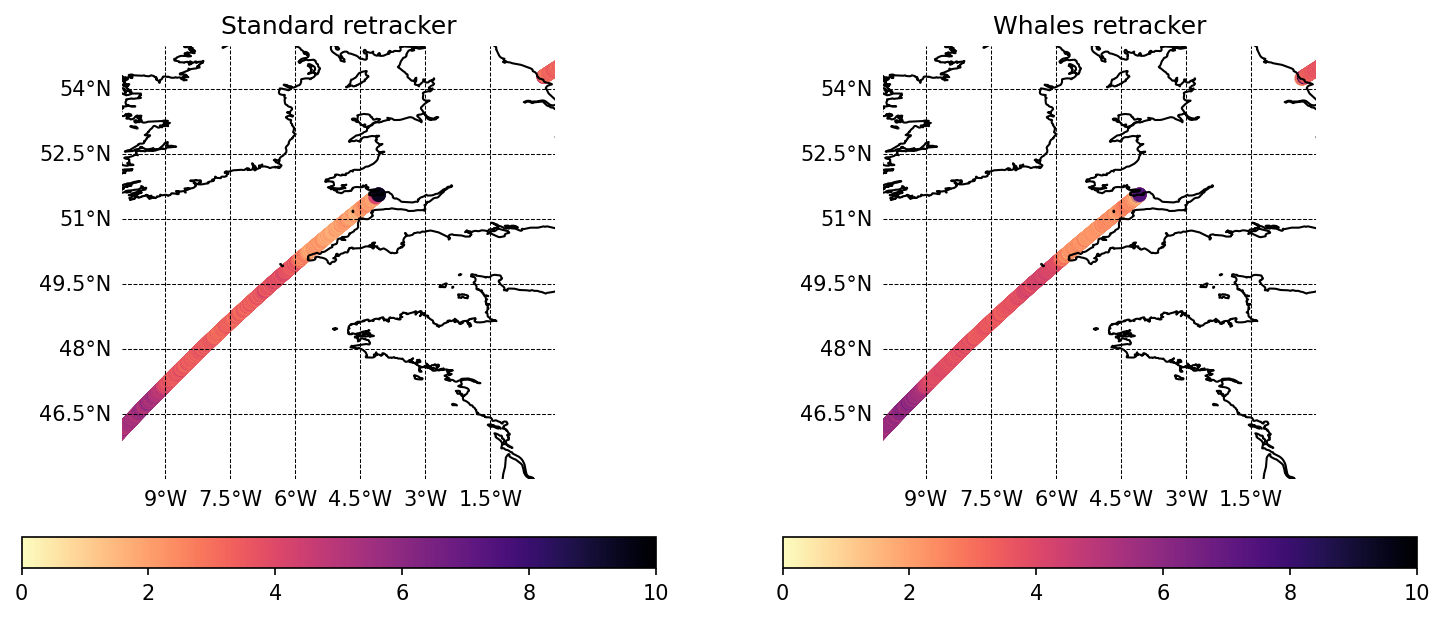

In [19]:
# spatial plots (limited to search box +/- pad)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, subplot_kw={"projection": cartopy.crs.PlateCarree()})

p1 = axes[0].scatter(filtered_ds_L2.longitude, filtered_ds_L2.latitude, c=filtered_ds_L2.swh_ocean, transform=cartopy.crs.PlateCarree(), vmin=vmin, vmax=vmax, cmap="magma_r")
axes[0].coastlines()
axes[0].set_title("Standard retracker")
axes[0].set_extent([west - map_pad, east + map_pad, south - map_pad, north + map_pad])
embellish_plot(axes[0])
cbar = fig.colorbar(p1, ax=axes[0], location='bottom', pad=0.1)

p2 = axes[1].scatter(filtered_ds_whales.lon_20hz, filtered_ds_whales.lat_20hz, c=filtered_ds_whales.swh_WHALES_20hz, transform=cartopy.crs.PlateCarree(), vmin=vmin, vmax=vmax, cmap="magma_r")
axes[1].coastlines()
axes[1].set_title("Whales retracker")
axes[1].set_extent([west - map_pad, east + map_pad, south - map_pad, north + map_pad])
embellish_plot(axes[1])
cbar = fig.colorbar(p2, ax=axes[1], location='bottom', pad=0.1)

plt.show()

In [20]:
# subset data by spatial box
filtered_ds_L1_subset = filtered_ds_L1.where((filtered_ds_L1.longitude > west) & 
                                             (filtered_ds_L1.longitude < east) & 
                                             (filtered_ds_L1.latitude > south) & 
                                             (filtered_ds_L1.latitude < north),
                                             drop=True)

filtered_ds_L2_subset = filtered_ds_L2.where((filtered_ds_L2.longitude > west) & 
                                             (filtered_ds_L2.longitude < east) & 
                                             (filtered_ds_L2.latitude > south) & 
                                             (filtered_ds_L2.latitude < north),
                                             drop=True)

filtered_ds_whales_subset = filtered_ds_whales.where((filtered_ds_whales.lon_20hz > west) & 
                                                     (filtered_ds_whales.lon_20hz < east) & 
                                                     (filtered_ds_whales.lat_20hz > south) & 
                                                     (filtered_ds_whales.lat_20hz < north),
                                                     drop=True)

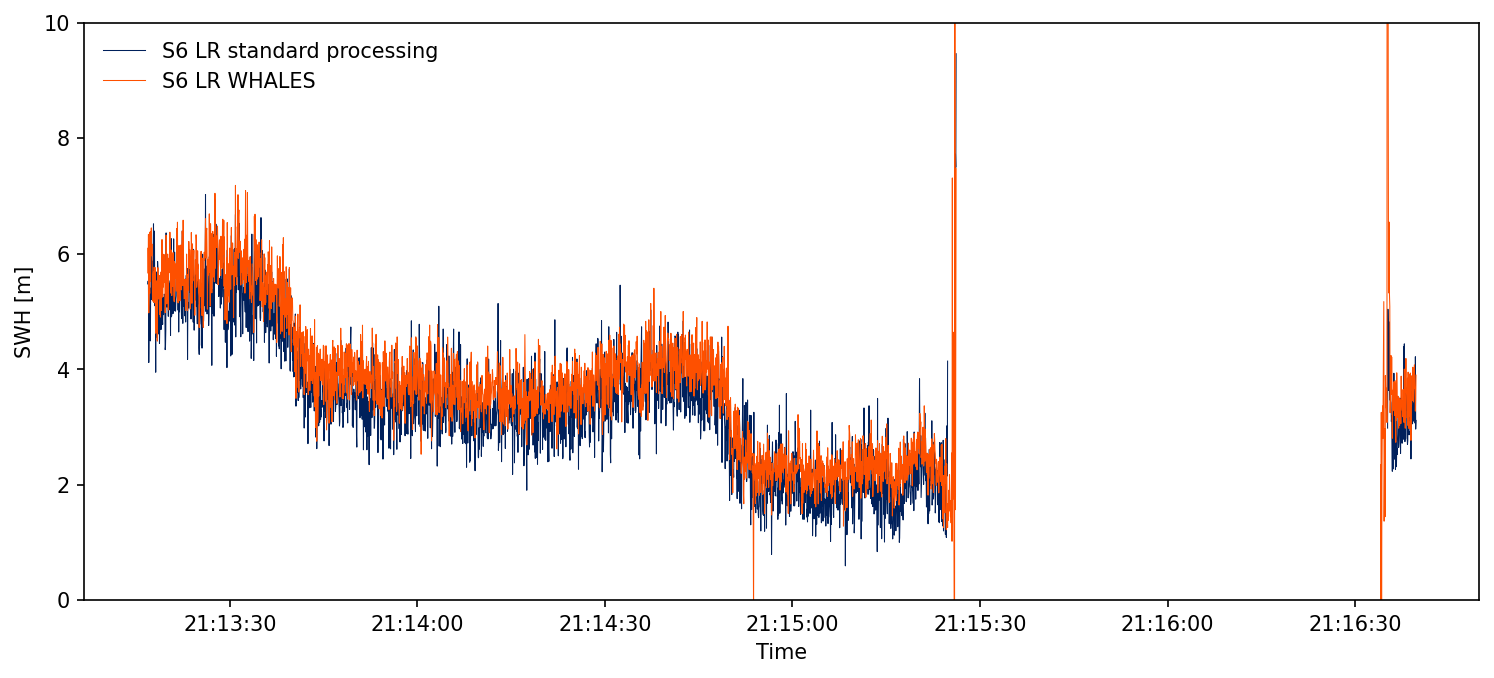

In [21]:
# compare against time base
fig, axis = plt.subplots(1, 1, figsize=(12, 5), dpi=150)
p1, = axis.plot(filtered_ds_L2_subset.time, filtered_ds_L2_subset.swh_ocean, '#00205b', linewidth=0.5)
p2, = axis.plot(filtered_ds_whales_subset.time, filtered_ds_whales_subset.swh_WHALES_20hz, '#fe5000', linewidth=0.5)
plt.ylim([0, threshold])
plt.ylabel("SWH [m]")
plt.xlabel("Time")
plt.legend([p1, p2], ["S6 LR standard processing", "S6 LR WHALES"], frameon=False)

In [107]:
ds_L2_01.index_first_20hz_measurement[indx_01].values
ds_L2_01.index_first_20hz_measurement[indx_01+1].values
indx_20 = [ds_L2_01.index_first_20hz_measurement[indx_01].values, ds_L2_01.index_first_20hz_measurement[indx_01+1].values]

39736.0


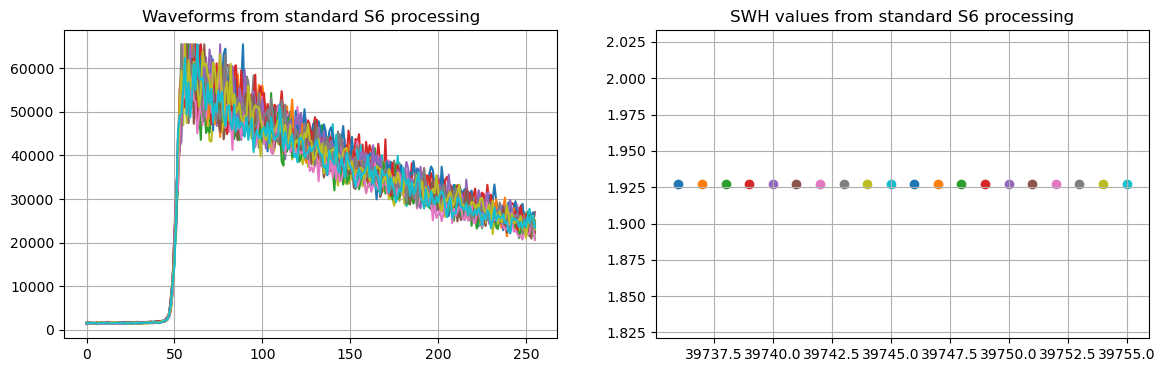

In [117]:
#Now we look at some waveforms ...
fig, axes = plt.subplots(1, 2, figsize=(14,4))

for indx in range(int(indx_20[0]), int(indx_20[1])):
    p1 = axes[0].plot(ds_L1.power_waveform[indx, :])
    p2 = axes[1].scatter(indx, ds_L2.swh_ocean[ind])

axes[0].set_title('Waveforms from standard S6 processing')
axes[0].grid(True)

axes[1].set_title('SWH values from standard S6 processing')
axes[1].grid(True)

<hr>
<a href="../../Index.ipynb"><< Index</a>
<hr>
<a href="https://gitlab.eumetsat.int/eumetlab/ocean" target="_blank">View on GitLab</a> | <a href="https://training.eumetsat.int/" target="_blank">EUMETSAT Training</a> | <a href=mailto:ops@eumetsat.int target="_blank">Contact helpdesk for support </a> | <a href=mailto:training@eumetsat.int target="_blank">Contact our training team to collaborate on and reuse this material</a></span></p>